# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 32: HYBRID MULTI-LABEL FUSION ON AUDIO PILOT
# ============================================================
# Purpose:
# This notebook combines the structured and unstructured
# multi-label branches on the exact same candidate-150 pilot
# validation and test sets.
#
# The goal is to:
# 1. Load aligned structured and audio pilot outputs
# 2. Verify track, label, and target alignment
# 3. Fuse structured and audio probabilities
# 4. Tune fusion weights and threshold on validation data
# 5. Evaluate the best hybrid model on the test set
# 6. Compare structured vs audio vs hybrid performance
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [2]:
# ============================================================
# 2. LOAD STRUCTURED PILOT OUTPUTS
# ============================================================

structured_val_probs = np.load("../data/processed/structured_on_audio_pilot_candidate150_val_probs.npy")
structured_test_probs = np.load("../data/processed/structured_on_audio_pilot_candidate150_test_probs.npy")

structured_y_val = np.load("../data/processed/structured_on_audio_pilot_candidate150_y_val.npy")
structured_y_test = np.load("../data/processed/structured_on_audio_pilot_candidate150_y_test.npy")

structured_val_track_ids = np.load("../data/processed/structured_on_audio_pilot_candidate150_val_track_ids.npy")
structured_test_track_ids = np.load("../data/processed/structured_on_audio_pilot_candidate150_test_track_ids.npy")

structured_label_cols = np.load(
    "../data/processed/structured_on_audio_pilot_candidate150_label_columns.npy",
    allow_pickle=True
)

structured_val_results_df = pd.read_csv(
    "../data/processed/structured_on_audio_pilot_candidate150_val_results.csv"
)
structured_test_results_df = pd.read_csv(
    "../data/processed/structured_on_audio_pilot_candidate150_test_results.csv"
)

print("Structured validation probabilities shape:", structured_val_probs.shape)
print("Structured test probabilities shape:", structured_test_probs.shape)
print("Structured y_val shape:", structured_y_val.shape)
print("Structured y_test shape:", structured_y_test.shape)

display(structured_test_results_df)

Structured validation probabilities shape: (1000, 150)
Structured test probabilities shape: (1000, 150)
Structured y_val shape: (1000, 150)
Structured y_test shape: (1000, 150)


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,Structured Model on Audio Pilot - Test,0.166223,0.083978,0.16727,0.097339,0.568596,0.14192,0.0,21.8


In [3]:
# ============================================================
# 3. LOAD AUDIO PILOT OUTPUTS
# ============================================================

audio_val_probs = np.load("../data/processed/audio_multilabel_candidate150_pilot_val_probs.npy")
audio_test_probs = np.load("../data/processed/audio_multilabel_candidate150_pilot_test_probs.npy")

audio_y_val = np.load("../data/processed/audio_multilabel_candidate150_pilot_y_val.npy")
audio_y_test = np.load("../data/processed/audio_multilabel_candidate150_pilot_y_test.npy")

audio_val_track_ids = np.load("../data/processed/audio_multilabel_candidate150_pilot_val_track_ids.npy")
audio_test_track_ids = np.load("../data/processed/audio_multilabel_candidate150_pilot_test_track_ids.npy")

audio_label_cols = np.load(
    "../data/processed/audio_multilabel_candidate150_pilot_label_columns.npy",
    allow_pickle=True
)

audio_test_comparison_df = pd.read_csv(
    "../data/processed/audio_multilabel_candidate150_pilot_test_comparison.csv"
)

with open("../data/processed/audio_multilabel_candidate150_pilot_best_threshold.txt", "r") as f:
    audio_best_threshold = float(f.read().strip())

print("Audio validation probabilities shape:", audio_val_probs.shape)
print("Audio test probabilities shape:", audio_test_probs.shape)
print("Audio y_val shape:", audio_y_val.shape)
print("Audio y_test shape:", audio_y_test.shape)
print("Audio best threshold:", audio_best_threshold)

display(audio_test_comparison_df)

Audio validation probabilities shape: (1000, 150)
Audio test probabilities shape: (1000, 150)
Audio y_val shape: (1000, 150)
Audio y_test shape: (1000, 150)
Audio best threshold: 0.15000000000000002


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Audio Multi-Label CNN - Default Threshold,0.250312,0.013248,0.247224,0.561682,0.161040,0.0240,0.006,1.070,0.402667,0.354601,0.313,0.449741
1,Audio Multi-Label CNN - Tuned Threshold,0.362377,0.042856,0.357893,0.322533,0.413451,0.0362,0.001,4.784,0.402667,0.354601,0.313,0.449741


In [4]:
# ============================================================
# 4. VERIFY FULL ALIGNMENT
# ============================================================

print("Label columns match:",
      np.array_equal(structured_label_cols, audio_label_cols))

print("Validation track IDs match:",
      np.array_equal(structured_val_track_ids, audio_val_track_ids))

print("Test track IDs match:",
      np.array_equal(structured_test_track_ids, audio_test_track_ids))

print("Validation targets match:",
      np.array_equal(structured_y_val, audio_y_val))

print("Test targets match:",
      np.array_equal(structured_y_test, audio_y_test))

assert np.array_equal(structured_label_cols, audio_label_cols), "Label columns do not match."
assert np.array_equal(structured_val_track_ids, audio_val_track_ids), "Validation track IDs do not match."
assert np.array_equal(structured_test_track_ids, audio_test_track_ids), "Test track IDs do not match."
assert np.array_equal(structured_y_val, audio_y_val), "Validation targets do not match."
assert np.array_equal(structured_y_test, audio_y_test), "Test targets do not match."

Label columns match: True
Validation track IDs match: True
Test track IDs match: True
Validation targets match: True
Test targets match: True


In [5]:
# ============================================================
# 5. DEFINE COMMON TARGETS
# ============================================================

Y_val = structured_y_val.copy()
Y_test = structured_y_test.copy()
label_cols = structured_label_cols.copy()

print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)
print("Number of labels:", len(label_cols))

Y_val shape: (1000, 150)
Y_test shape: (1000, 150)
Number of labels: 150


In [6]:
# ============================================================
# 6. EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def decode_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def fuse_probabilities(structured_probs, audio_probs, w_structured=0.5, w_audio=0.5):
    return (w_structured * structured_probs) + (w_audio * audio_probs)

In [7]:
# ============================================================
# 7. BASELINE COMPARISON ON THE SAME PILOT
# ============================================================

structured_baseline_pred = decode_threshold(structured_val_probs, 0.5, ensure_at_least_one=False)
audio_baseline_pred = decode_threshold(audio_val_probs, audio_best_threshold, ensure_at_least_one=False)

structured_baseline_results = evaluate_multilabel(
    Y_val, structured_baseline_pred, name="Structured Pseudo-Prob @ 0.50"
)

audio_baseline_results = evaluate_multilabel(
    Y_val, audio_baseline_pred, name=f"Audio CNN @ {audio_best_threshold:.2f}"
)

print("Validation structured baseline from pseudo-probs:")
print(structured_baseline_results)

print("\nValidation audio baseline:")
print(audio_baseline_results)

Validation structured baseline from pseudo-probs:
{'Model': 'Structured Pseudo-Prob @ 0.50', 'Micro F1': 0.1653298029748462, 'Macro F1': 0.08045674757604226, 'Samples F1': 0.1659257595054056, 'Micro Precision': 0.09754640691049439, 'Micro Recall': 0.541858090862685, 'Hamming Loss': 0.14290666666666665, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 21.764}

Validation audio baseline:
{'Model': 'Audio CNN @ 0.15', 'Micro F1': 0.35658029905261956, 'Macro F1': 0.03804897259136516, 'Samples F1': 0.35239049006549006, 'Micro Precision': 0.32252735907495356, 'Micro Recall': 0.39867279224093927, 'Hamming Loss': 0.03758, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 4.843}


In [8]:
# ============================================================
# 8. FUSION SEARCH ON VALIDATION
# ============================================================

weight_grid = np.arange(0.0, 1.01, 0.1)
threshold_grid = np.arange(0.05, 0.55, 0.05)

fusion_results = []

for w_structured in weight_grid:
    w_audio = 1.0 - w_structured

    fused_val_probs = fuse_probabilities(
        structured_val_probs,
        audio_val_probs,
        w_structured=w_structured,
        w_audio=w_audio
    )

    for threshold in threshold_grid:
        fused_val_pred = decode_threshold(
            fused_val_probs,
            threshold=threshold,
            ensure_at_least_one=False
        )

        results = evaluate_multilabel(
            Y_val,
            fused_val_pred,
            name=f"Fusion S={w_structured:.1f} A={w_audio:.1f} T={threshold:.2f}"
        )

        results["Structured Weight"] = float(w_structured)
        results["Audio Weight"] = float(w_audio)
        results["Threshold"] = float(threshold)

        fusion_results.append(results)

fusion_results_df = pd.DataFrame(fusion_results).sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).reset_index(drop=True)

print("Fusion validation search results:")
display(fusion_results_df.head(20))

Fusion validation search results:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Structured Weight,Audio Weight,Threshold
0,Fusion S=0.1 A=0.9 T=0.20,0.371005,0.047075,0.366223,0.339551,0.408882,0.036213,0.002,4.718,0.1,0.9,0.20
1,Fusion S=0.1 A=0.9 T=0.25,0.370075,0.036911,0.366353,0.417925,0.332057,0.029527,0.005,3.113,0.1,0.9,0.25
2,Fusion S=0.2 A=0.8 T=0.30,0.369153,0.042549,0.365372,0.383852,0.355539,0.031740,0.005,3.629,0.2,0.8,0.30
3,Fusion S=0.2 A=0.8 T=0.35,0.357278,0.033848,0.355983,0.470025,0.288157,0.027080,0.010,2.402,0.2,0.8,0.35
4,Fusion S=0.0 A=1.0 T=0.15,0.356580,0.038049,0.352390,0.322527,0.398673,0.037580,0.000,4.843,0.0,1.0,0.15
5,Fusion S=0.0 A=1.0 T=0.20,0.355382,0.031234,0.351025,0.391051,0.325676,0.030860,0.002,3.263,0.0,1.0,0.20
6,Fusion S=0.3 A=0.7 T=0.40,0.352994,0.038262,0.347535,0.423820,0.302450,0.028960,0.012,2.796,0.3,0.7,0.40
7,Fusion S=0.2 A=0.8 T=0.25,0.352593,0.057870,0.348498,0.287275,0.456355,0.043773,0.000,6.224,0.2,0.8,0.25
8,Fusion S=0.3 A=0.7 T=0.35,0.352219,0.054220,0.347657,0.308623,0.410158,0.039407,0.003,5.207,0.3,0.7,0.35
9,Fusion S=0.1 A=0.9 T=0.30,0.351603,0.027948,0.350536,0.472438,0.279990,0.026973,0.009,2.322,0.1,0.9,0.30


In [9]:
# ============================================================
# 9. SELECT BEST HYBRID CONFIGURATION
# ============================================================

best_row = fusion_results_df.iloc[0].to_dict()

best_w_structured = float(best_row["Structured Weight"])
best_w_audio = float(best_row["Audio Weight"])
best_threshold = float(best_row["Threshold"])

print("Best hybrid configuration:")
print("Structured weight:", best_w_structured)
print("Audio weight:", best_w_audio)
print("Threshold:", best_threshold)
print("Best validation Micro F1:", best_row["Micro F1"])

Best hybrid configuration:
Structured weight: 0.1
Audio weight: 0.9
Threshold: 0.2
Best validation Micro F1: 0.37100509495136635


In [10]:
# ============================================================
# 10. APPLY BEST HYBRID CONFIGURATION TO TEST
# ============================================================

fused_test_probs = fuse_probabilities(
    structured_test_probs,
    audio_test_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

fused_test_pred = decode_threshold(
    fused_test_probs,
    threshold=best_threshold,
    ensure_at_least_one=False
)

hybrid_test_results = evaluate_multilabel(
    Y_test,
    fused_test_pred,
    name="Hybrid Multi-Label Fusion"
)

p3_test_hybrid, r3_test_hybrid = precision_recall_at_k(Y_test, fused_test_probs, k=3)
p5_test_hybrid, r5_test_hybrid = precision_recall_at_k(Y_test, fused_test_probs, k=5)

hybrid_test_results["Precision@3"] = p3_test_hybrid
hybrid_test_results["Recall@3"] = r3_test_hybrid
hybrid_test_results["Precision@5"] = p5_test_hybrid
hybrid_test_results["Recall@5"] = r5_test_hybrid

print("Hybrid test results:")
print(hybrid_test_results)

Hybrid test results:
{'Model': 'Hybrid Multi-Label Fusion', 'Micro F1': 0.3783526046012636, 'Macro F1': 0.04930099343344162, 'Samples F1': 0.37267043136601957, 'Micro Precision': 0.34077732445780545, 'Micro Recall': 0.4252411575562701, 'Hamming Loss': 0.03476666666666667, 'Subset Accuracy': 0.001, 'Avg Predicted Labels': 4.657, 'Precision@3': 0.417, 'Recall@3': 0.3709108585858586, 'Precision@5': 0.32600000000000007, 'Recall@5': 0.4716756854256854}


In [11]:
# ============================================================
# 11. BUILD STRUCTURED / AUDIO / HYBRID TEST COMPARISON
# ============================================================

structured_test_pred_from_probs = decode_threshold(
    structured_test_probs,
    threshold=0.5,
    ensure_at_least_one=False
)

audio_test_pred_from_probs = decode_threshold(
    audio_test_probs,
    threshold=audio_best_threshold,
    ensure_at_least_one=False
)

structured_test_results = evaluate_multilabel(
    Y_test,
    structured_test_pred_from_probs,
    name="Structured Pseudo-Prob @ 0.50"
)

audio_test_results = evaluate_multilabel(
    Y_test,
    audio_test_pred_from_probs,
    name=f"Audio CNN @ {audio_best_threshold:.2f}"
)

p3_struct, r3_struct = precision_recall_at_k(Y_test, structured_test_probs, k=3)
p5_struct, r5_struct = precision_recall_at_k(Y_test, structured_test_probs, k=5)

structured_test_results["Precision@3"] = p3_struct
structured_test_results["Recall@3"] = r3_struct
structured_test_results["Precision@5"] = p5_struct
structured_test_results["Recall@5"] = r5_struct

p3_audio, r3_audio = precision_recall_at_k(Y_test, audio_test_probs, k=3)
p5_audio, r5_audio = precision_recall_at_k(Y_test, audio_test_probs, k=5)

audio_test_results["Precision@3"] = p3_audio
audio_test_results["Recall@3"] = r3_audio
audio_test_results["Precision@5"] = p5_audio
audio_test_results["Recall@5"] = r5_audio

comparison_df = pd.DataFrame([
    structured_test_results,
    audio_test_results,
    hybrid_test_results
])

print("Structured vs Audio vs Hybrid test comparison:")
display(comparison_df)

Structured vs Audio vs Hybrid test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Structured Pseudo-Prob @ 0.50,0.163705,0.083508,0.164850,0.095817,0.561629,0.142767,0.000,21.875,0.091333,0.077065,0.0872,0.125518
1,Audio CNN @ 0.15,0.362377,0.042856,0.357893,0.322533,0.413451,0.036200,0.001,4.784,0.402667,0.354601,0.3130,0.449741
2,Hybrid Multi-Label Fusion,0.378353,0.049301,0.372670,0.340777,0.425241,0.034767,0.001,4.657,0.417000,0.370911,0.3260,0.471676


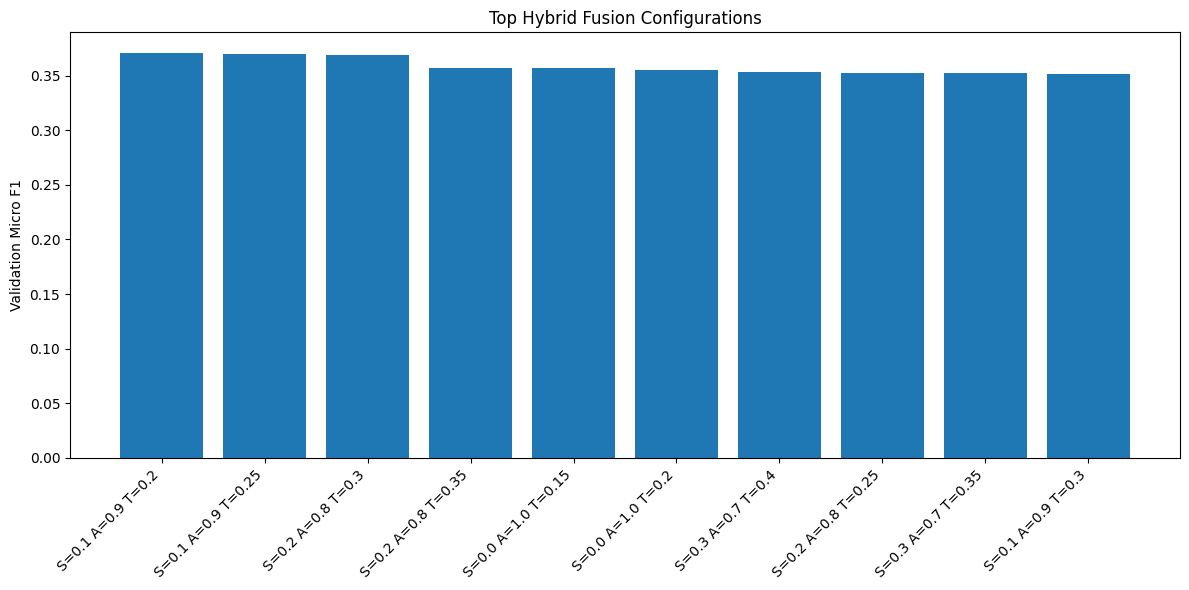

In [12]:
# ============================================================
# 12. PLOT TOP FUSION RESULTS
# ============================================================

plot_df = fusion_results_df.head(10).copy()
plot_df["Setting"] = (
    "S=" + plot_df["Structured Weight"].round(1).astype(str) +
    " A=" + plot_df["Audio Weight"].round(1).astype(str) +
    " T=" + plot_df["Threshold"].round(2).astype(str)
)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Setting"], plot_df["Micro F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Micro F1")
plt.title("Top Hybrid Fusion Configurations")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 13. SAVE HYBRID OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

fusion_results_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_fusion_search.csv",
    index=False
)

pd.DataFrame([hybrid_test_results]).to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_test_results.csv",
    index=False
)

comparison_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_pilot_model_comparison.csv",
    index=False
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_test_probs.npy",
    fused_test_probs
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_test_pred.npy",
    fused_test_pred
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_y_test.npy",
    Y_test
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_test_track_ids.npy",
    structured_test_track_ids
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_pilot_label_columns.npy",
    np.array(label_cols)
)

with open("../data/processed/hybrid_multilabel_candidate150_pilot_best_config.txt", "w") as f:
    f.write(
        f"structured_weight={best_w_structured}\n"
        f"audio_weight={best_w_audio}\n"
        f"threshold={best_threshold}\n"
    )

print("Saved hybrid multi-label pilot outputs.")

Saved hybrid multi-label pilot outputs.


In [14]:
# ============================================================
# 14. INTERPRETATION NOTES
# ============================================================

print("1. This notebook combines the structured and audio multi-label branches on the exact same pilot split.")
print("2. Fusion is performed by weighted averaging of structured pseudo-probabilities and audio probabilities.")
print("3. Validation data is used to tune both fusion weights and the final decision threshold.")
print("4. The final comparison shows whether the hybrid system improves over the audio-only baseline.")
print("5. The saved hybrid outputs can be used in the report, presentation, and later deployment-style demos.")

1. This notebook combines the structured and audio multi-label branches on the exact same pilot split.
2. Fusion is performed by weighted averaging of structured pseudo-probabilities and audio probabilities.
3. Validation data is used to tune both fusion weights and the final decision threshold.
4. The final comparison shows whether the hybrid system improves over the audio-only baseline.
5. The saved hybrid outputs can be used in the report, presentation, and later deployment-style demos.
